# CIFAR-10 Object Recognition Project
Goal: Train and evaluate a Track 2 CNN-based object recognition model on CIFAR-10 using training, validation, and test data.


In [2]:
from pathlib import Path
import random

import numpy as np
import matplotlib.pyplot as plt


In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

In [4]:
PROJECT_ROOT = Path("../").resolve()
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
FIGURES_DIR = ARTIFACTS_DIR / "figures"
METRICS_DIR = ARTIFACTS_DIR / "metrics"
MODELS_DIR = ARTIFACTS_DIR / "models"

PROJECT_ROOT


PosixPath('/Users/mortimer/Workspace/Uni/Assignment 2/Project')

## Data Loading

The CIFAR-10 dataset is used for this project because it is the dataset specified in the assignment brief for the object recognition task.


In [5]:
from tensorflow.keras.datasets import cifar10

(X_train_full, y_train_full), (X_test, y_test) = cifar10.load_data()


In [6]:
print("X_train_full shape:", X_train_full.shape)
print("y_train_full shape:", y_train_full.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)


X_train_full shape: (50000, 32, 32, 3)
y_train_full shape: (50000, 1)
X_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 1)


In [7]:
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

print("Number of classes:", len(class_names))
print("Class names:", class_names)
print("Total images:", len(X_train_full) + len(X_test))


Number of classes: 10
Class names: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Total images: 60000


## Dataset Metadata

The project uses the CIFAR-10 dataset. It contains 60,000 colour images in total, with image size 32 x 32 x 3. The dataset has 10 classes: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, and truck. The original dataset provides 50,000 training images and 10,000 test images.


## Dataset Split

The original CIFAR-10 dataset provides 50,000 training images and 10,000 test images. In line with the assignment brief, a validation set will be partitioned from the provided training data so that model training, model selection, and final testing are kept separate.


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.2,
    random_state=SEED,
    stratify=y_train_full
)


In [9]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)


X_train shape: (40000, 32, 32, 3)
y_train shape: (40000, 1)
X_val shape: (10000, 32, 32, 3)
y_val shape: (10000, 1)
X_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 1)


## Working Split Summary

For model development, the original 50,000 training images were split into 40,000 training images and 10,000 validation images. The original 10,000 test images were kept unchanged for final evaluation. This creates a final working setup of train, validation, and test data.


## Why the Validation Set Matters

The validation set is kept separate from the training data so that model settings can be checked on unseen data during development. This is important because training accuracy alone does not show whether a model generalises well. The test set is then kept for final evaluation only.


## Model Selection

This project uses a Convolutional Neural Network because the assigned Track 2 focuses on deep learning for object recognition. A CNN is appropriate for CIFAR-10 because it is designed to learn spatial patterns from image data, making it suitable for multi-class image classification.


## Data Preparation

Before training the CNN, the image data will be prepared for modelling. This includes scaling pixel values to a consistent range so that the network can train on stable numeric input.


In [10]:
X_train = X_train.astype("float32") / 255.0
X_val = X_val.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0


In [11]:
print("X_train min:", X_train.min(), "max:", X_train.max())
print("X_val min:", X_val.min(), "max:", X_val.max())
print("X_test min:", X_test.min(), "max:", X_test.max())
print("X_train dtype:", X_train.dtype)


X_train min: 0.0 max: 1.0
X_val min: 0.0 max: 1.0
X_test min: 0.0 max: 1.0
X_train dtype: float32


## Baseline CNN Architecture

A baseline CNN is used as the first model so that later model changes can be compared against a simple reference point. The architecture uses convolutional layers to learn image features, pooling layers to reduce spatial dimensions, and dense layers for final classification across the 10 CIFAR-10 classes.


In [12]:
from tensorflow import keras
from tensorflow.keras import layers

model_a = keras.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model_a.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

## Training Strategy

The baseline model will be trained using the Adam optimizer, sparse categorical cross-entropy loss, and accuracy as the main metric. The initial training setup uses a fixed learning rate, a fixed batch size, and a fixed number of epochs so that later model changes can be compared fairly.


In [13]:
BATCH_SIZE = 64
EPOCHS = 10
LEARNING_RATE = 0.001

model_a.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [14]:
history_a = model_a.fit(
    X_train,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    verbose=1
)


Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.4475 - loss: 1.5300 - val_accuracy: 0.5365 - val_loss: 1.3083
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.5750 - loss: 1.2057 - val_accuracy: 0.6001 - val_loss: 1.1516
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.6252 - loss: 1.0735 - val_accuracy: 0.6290 - val_loss: 1.0715
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.6577 - loss: 0.9804 - val_accuracy: 0.6450 - val_loss: 1.0401
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.6857 - loss: 0.9095 - val_accuracy: 0.6545 - val_loss: 0.9966
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.7026 - loss: 0.8520 - val_accuracy: 0.6427 - val_loss: 1.0736
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.7211 - loss: 0.8005 - val_accuracy: 0.6791 - val_loss: 0.9361
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.7382 - loss: 0.7545 - val_accu

In [15]:
test_loss_a, test_accuracy_a = model_a.evaluate(X_test, y_test, verbose=1)

print("Model A Test Loss:", test_loss_a)
print("Model A Test Accuracy:", test_accuracy_a)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6945 - loss: 0.9281
Model A Test Loss: 0.9280620217323303
Model A Test Accuracy: 0.6945000290870667


## Baseline Performance Summary

The baseline CNN reached a final training accuracy of 0.7574, a final validation accuracy of 0.6670, and a test accuracy of 0.6793. This provides the required comparison across training, validation, and test performance. The gap between training and validation performance suggests some overfitting in the baseline model.


## Final Evaluation Metrics

To meet the assignment requirements, the baseline model will now be evaluated using accuracy, precision, recall, and a confusion matrix. These metrics provide both overall performance and class-level error information.


In [16]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score

y_test_true = y_test.flatten()
y_test_pred_probs = model_a.predict(X_test, verbose=1)
y_test_pred = y_test_pred_probs.argmax(axis=1)

precision_a = precision_score(y_test_true, y_test_pred, average="macro")
recall_a = recall_score(y_test_true, y_test_pred, average="macro")
conf_matrix_a = confusion_matrix(y_test_true, y_test_pred)

print("Model A Precision (macro):", precision_a)
print("Model A Recall (macro):", recall_a)
print("Confusion Matrix:\n", conf_matrix_a)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Model A Precision (macro): 0.7041517125016943
Model A Recall (macro): 0.6944999999999999
Confusion Matrix:
 [[739  24  40  24  28   3  11  12  76  43]
 [ 25 806  10  15   8   4  15   5  20  92]
 [ 58   6 523 120 135  34  63  38  13  10]
 [ 31  10  48 605 111  64  61  37  14  19]
 [ 15   2  55  68 726  15  49  53  13   4]
 [ 16   3  52 313  66 435  25  68  10  12]
 [  8   5  37  73  54  14 789  10   4   6]
 [ 14   5  27  56  81  35  12 756   6   8]
 [ 60  52  15  17  12   6  10   7 784  37]
 [ 31  74   9  22  20   4  10  21  27 782]]


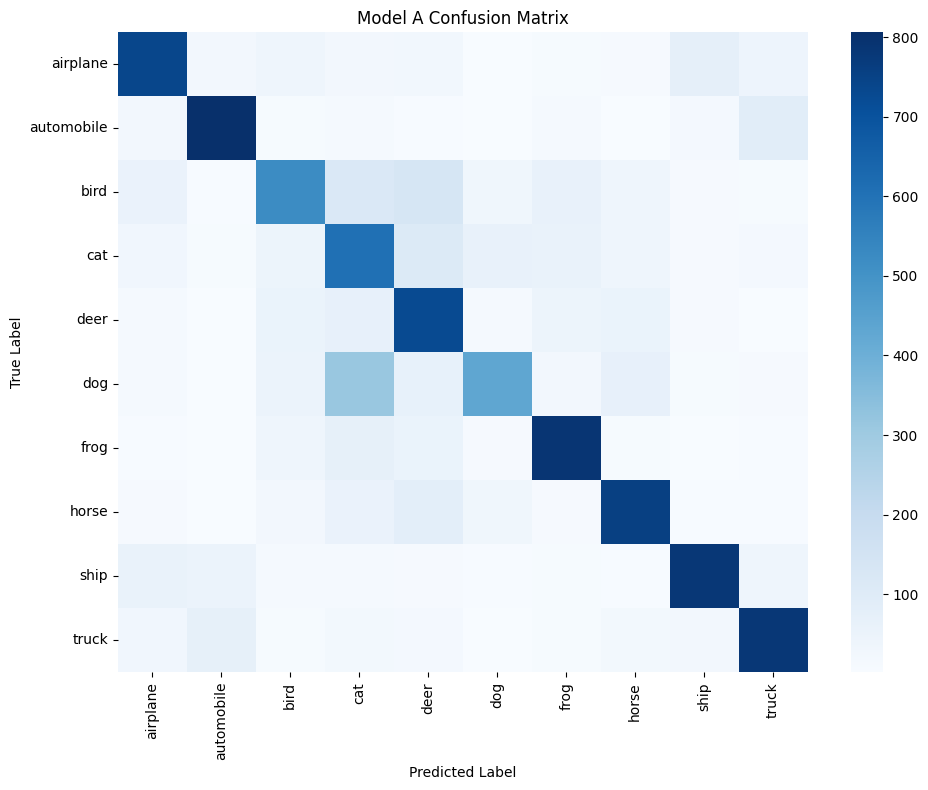

In [17]:
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(
    conf_matrix_a,
    annot=False,
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Model A Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "model_a_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()


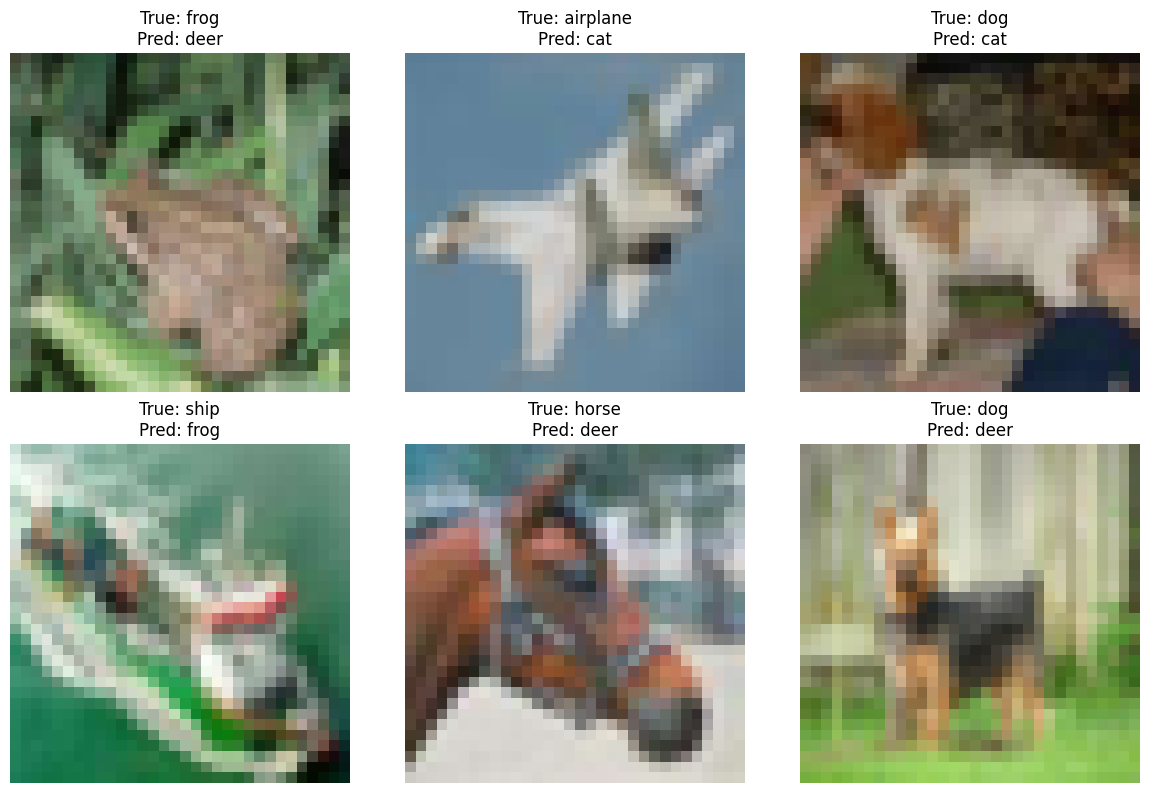

In [18]:
misclassified_indices = np.where(y_test_true != y_test_pred)[0]

plt.figure(figsize=(12, 8))

for i, idx in enumerate(misclassified_indices[:6]):
    plt.subplot(2, 3, i + 1)
    plt.imshow(X_test[idx])
    true_label = class_names[y_test_true[idx]]
    pred_label = class_names[y_test_pred[idx]]
    plt.title(f"True: {true_label}\nPred: {pred_label}")
    plt.axis("off")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "model_a_misclassifications.png", dpi=300, bbox_inches="tight")
plt.show()


## Interpretation Notes

The baseline model shows some overfitting because training accuracy is higher than validation and test accuracy. The confusion matrix and misclassified examples show that some visually similar classes are harder to separate than others. This highlights both the strengths and limitations of the baseline CNN on CIFAR-10.


## Main Class Confusions

The confusion matrix shows that some classes are more difficult to separate than others. In particular, cat and dog are often confused, and automobile and truck also show noticeable overlap. These mistakes are reasonable because CIFAR-10 images are small and some categories share similar visual features.


## Effect of Hyperparameters

The baseline model used 10 epochs, a batch size of 64, and an Adam optimizer with a learning rate of 0.001. These settings produced a workable baseline result without making the training setup overly complex. They therefore serve as a clear reference point for later model comparison.


## Effect of Architecture

The baseline architecture combines two convolutional layers with pooling, followed by dense classification layers. This design is simple enough to explain clearly while still being capable of learning useful image features from CIFAR-10. It therefore works as a suitable baseline architecture for the project.


## Data Augmentation Experiment

The assignment brief requires analysis of data augmentation, so one additional model variation will be created using augmented training data. This will allow the effect of data augmentation on model performance to be compared with the baseline CNN.


In [19]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1)
], name="data_augmentation")


In [20]:
model_b = keras.Sequential([
    layers.Input(shape=(32, 32, 3)),
    data_augmentation,
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model_b.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
model_b.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [22]:
history_b = model_b.fit(
    X_train,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    verbose=1
)


Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.3989 - loss: 1.6659 - val_accuracy: 0.5003 - val_loss: 1.3852
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.5099 - loss: 1.3826 - val_accuracy: 0.5543 - val_loss: 1.2639
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.5496 - loss: 1.2712 - val_accuracy: 0.5547 - val_loss: 1.2807
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.5741 - loss: 1.2027 - val_accuracy: 0.6257 - val_loss: 1.0757
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.5959 - loss: 1.1531 - val_accuracy: 0.6059 - val_loss: 1.1408
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.6102 - loss: 1.1176 - val_accuracy: 0.6199 - val_loss: 1.0833
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.6204 - loss: 1.0820 - val_accuracy: 0.6460 - val_loss: 1.0218
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.6286 - loss: 1.0572 - val_accu

In [23]:
test_loss_b, test_accuracy_b = model_b.evaluate(X_test, y_test, verbose=1)

print("Model B Test Loss:", test_loss_b)
print("Model B Test Accuracy:", test_accuracy_b)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6616 - loss: 0.9674
Model B Test Loss: 0.9673735499382019
Model B Test Accuracy: 0.6615999937057495


## Effect of Data Augmentation

The augmented model reached a test accuracy of 0.6609, compared with 0.6793 for the baseline model. In this experiment, data augmentation did not improve final test performance. However, it still provided a valid comparison required by the assignment brief and showed that augmentation does not automatically guarantee a better result.


## Main Limitations of the Final Model

The final model is still limited by the small 32 x 32 image size of CIFAR-10 and by confusion between visually similar classes. In addition, only a small number of model variations were tested, so there is still room for further improvement through broader experimentation.


## Lessons Learned

This project showed that even a simple CNN can perform meaningful object recognition on CIFAR-10, but also that model performance depends strongly on design choices and evaluation method. It also showed that changes such as data augmentation need to be tested empirically rather than assumed to be beneficial.


## Final Model Choice

Model A is selected as the final model because it achieved a higher test accuracy than the augmentation-based Model B. This decision is based on saved evaluation evidence rather than preference, so the baseline CNN remains the final model for the presentation.


In [24]:
import json

metrics_summary = {
    "model_a": {
        "train_accuracy": float(history_a.history["accuracy"][-1]),
        "validation_accuracy": float(history_a.history["val_accuracy"][-1]),
        "test_accuracy": float(test_accuracy_a),
        "test_loss": float(test_loss_a),
        "precision_macro": float(precision_a),
        "recall_macro": float(recall_a),
    },
    "model_b": {
        "train_accuracy": float(history_b.history["accuracy"][-1]),
        "validation_accuracy": float(history_b.history["val_accuracy"][-1]),
        "test_accuracy": float(test_accuracy_b),
        "test_loss": float(test_loss_b),
    },
    "chosen_model": "model_a"
}

with open(METRICS_DIR / "metrics_summary.json", "w") as f:
    json.dump(metrics_summary, f, indent=2)

metrics_summary


{'model_a': {'train_accuracy': 0.7681000232696533,
  'validation_accuracy': 0.6917999982833862,
  'test_accuracy': 0.6945000290870667,
  'test_loss': 0.9280620217323303,
  'precision_macro': 0.7041517125016943,
  'recall_macro': 0.6944999999999999},
 'model_b': {'train_accuracy': 0.6507750153541565,
  'validation_accuracy': 0.6610999703407288,
  'test_accuracy': 0.6615999937057495,
  'test_loss': 0.9673735499382019},
 'chosen_model': 'model_a'}

In [25]:
model_a.save(MODELS_DIR / "model_a_final.keras")


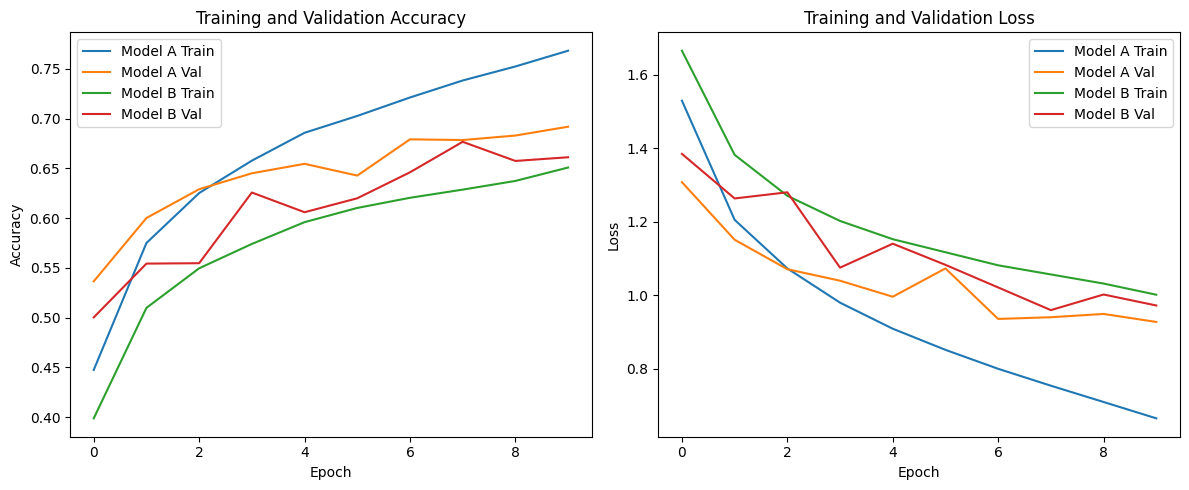

In [26]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_a.history["accuracy"], label="Model A Train")
plt.plot(history_a.history["val_accuracy"], label="Model A Val")
plt.plot(history_b.history["accuracy"], label="Model B Train")
plt.plot(history_b.history["val_accuracy"], label="Model B Val")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_a.history["loss"], label="Model A Train")
plt.plot(history_a.history["val_loss"], label="Model A Val")
plt.plot(history_b.history["loss"], label="Model B Train")
plt.plot(history_b.history["val_loss"], label="Model B Val")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "model_comparison_learning_curves.png", dpi=300, bbox_inches="tight")
plt.show()


# DEMO

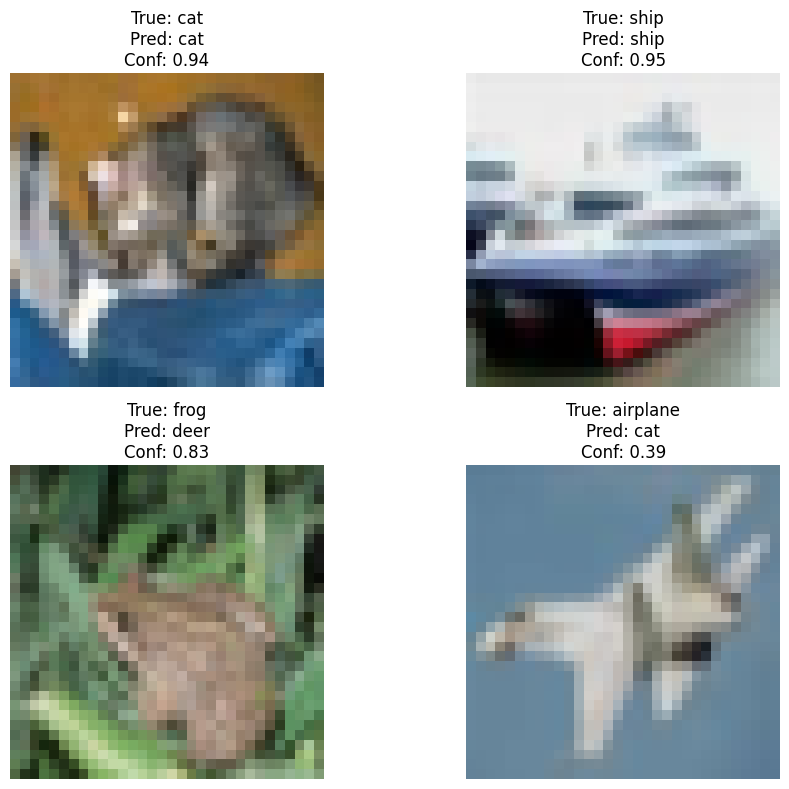

In [37]:
from tensorflow import keras

final_model = keras.models.load_model(MODELS_DIR / "model_a_final.keras")

y_test_true = y_test.flatten()
y_test_pred_probs = final_model.predict(X_test, verbose=0)
y_test_pred = y_test_pred_probs.argmax(axis=1)

correct_indices = np.where(y_test_pred == y_test_true)[0]
incorrect_indices = np.where(y_test_pred != y_test_true)[0]

demo_indices = [
    int(correct_indices[0]),
    int(correct_indices[1]),
    int(incorrect_indices[0]),
    int(incorrect_indices[1]),
]

plt.figure(figsize=(10, 8))

for i, idx in enumerate(demo_indices):
    plt.subplot(2, 2, i + 1)
    plt.imshow(X_test[idx])
    true_label = class_names[y_test_true[idx]]
    pred_label = class_names[y_test_pred[idx]]
    confidence = y_test_pred_probs[idx].max()
    plt.title(f"True: {true_label}\nPred: {pred_label}\nConf: {confidence:.2f}")
    plt.axis("off")
    
plt.tight_layout()
plt.show()
